# Tokenizer Demo
Walks through the ceol-gpt word-based ABC tokenizer: vocab stats, round-trips, and edge cases.

In [1]:
# ── Colab setup ──────────────────────────────────────────────────────────────
import sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/ceol-gpt   # adjust path if needed
    %pip install -q pyyaml tqdm matplotlib
else:
    # Local: ensure we're running from the project root
    root = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
    os.chdir(root)

# Ensure src/ is importable regardless of how the kernel was launched
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

In [2]:
import json
from collections import Counter
import matplotlib.pyplot as plt

from src.tokenizer import ABCTokenizer, tokenize_abc, _first_note_from_chord

with open('data/tunes.json') as f:
    tunes = json.load(f)

print(f'Loaded {len(tunes):,} tunes')

Loaded 54,246 tunes


## 1. Build vocabulary

In [3]:
tokenizer = ABCTokenizer.from_tunes(tunes, min_freq=2)
vocab = tokenizer.vocab.token_to_id

print(f'Vocabulary size: {len(tokenizer):,}')
print(f'  pad={tokenizer.pad_id}  bos={tokenizer.bos_id}  eos={tokenizer.eos_id}')

Vocabulary size: 932
  pad=0  bos=1  eos=2


In [4]:
import re

music_tokens = [t for t in vocab if not t.startswith('<')]
special_tokens = [t for t in vocab if t.startswith('<')]

notes    = [t for t in music_tokens if re.match(r'^[\^_=]?[A-Ga-g]', t)]
rests    = [t for t in music_tokens if re.match(r'^[zxZ]', t)]
barlines = [t for t in music_tokens if any(c in t for c in '|:') or t == '::']
decos    = [t for t in music_tokens if len(t) == 1 and t in '~.THuvJLMPS']
tuplets  = [t for t in music_tokens if t.startswith('(')]
broken   = [t for t in music_tokens if t[0] in '><']
endings  = [t for t in music_tokens if re.match(r'\[\d|\|\d', t)]
other    = [t for t in music_tokens
            if t not in notes+rests+barlines+decos+tuplets+broken+endings]

categories = {
    'Notes':        notes,
    'Rests':        rests,
    'Bar lines':    barlines,
    'Decorations':  decos,
    'Tuplets':      tuplets,
    'Broken rhythm':broken,
    'Endings':      endings,
    'Other':        other,
    'Special/cond': special_tokens,
}

for name, tokens in categories.items():
    print(f'  {name:15s}: {len(tokens):4d}   e.g. {tokens[:6]}')

  Notes          :  826   e.g. ['=A', '=A,', '=A,2', '=A/', '=A2', '=A3']
  Rests          :   28   e.g. ['Z', 'x', 'x/', 'x//', 'x/2', 'x2']
  Bar lines      :    9   e.g. ['::', ':|', '|', '|1', '|2', '|3']
  Decorations    :   11   e.g. ['.', 'H', 'J', 'L', 'M', 'P']
  Tuplets        :    7   e.g. ['(1', '(2', '(3', '(4', '(5', '(6']
  Broken rhythm  :    2   e.g. ['>', '>>']
  Endings        :    8   e.g. ['[1', '[2', '[3', '[4', '|1', '|2']
  Other          :    4   e.g. ['-', '^^e', '^^f', '_z']
  Special/cond   :   41   e.g. ['<PAD>', '<BOS>', '<EOS>', '<UNK>', '<TYPE:barndance>', '<TYPE:hornpipe>']


## 2. Token frequency distribution

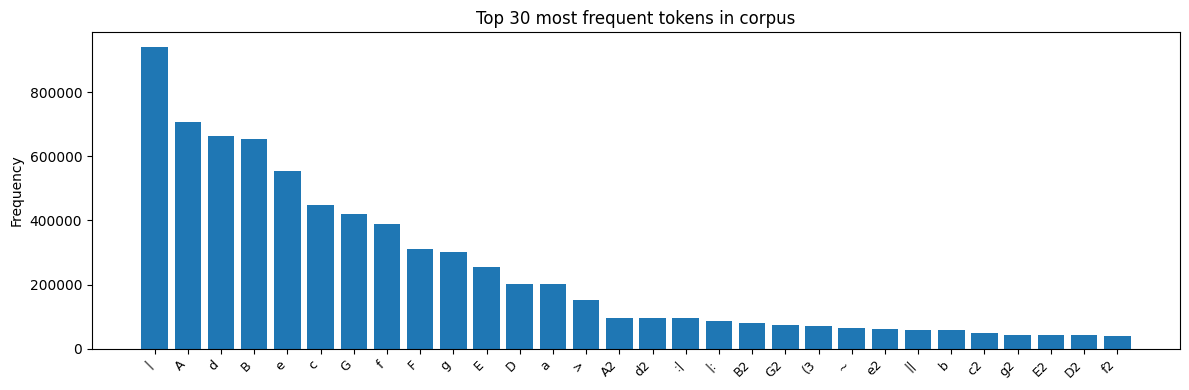

Total tokens in corpus: 8,107,210


In [5]:
counter = Counter()
for tune in tunes:
    counter.update(tokenize_abc(tune['abc']))

most_common = counter.most_common(30)
tokens_mc, counts_mc = zip(*most_common)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(tokens_mc)), counts_mc)
ax.set_xticks(range(len(tokens_mc)))
ax.set_xticklabels(tokens_mc, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Frequency')
ax.set_title('Top 30 most frequent tokens in corpus')
plt.tight_layout()
plt.show()

total_tokens = sum(counter.values())
print(f'Total tokens in corpus: {total_tokens:,}')

## 3. Sequence length distribution

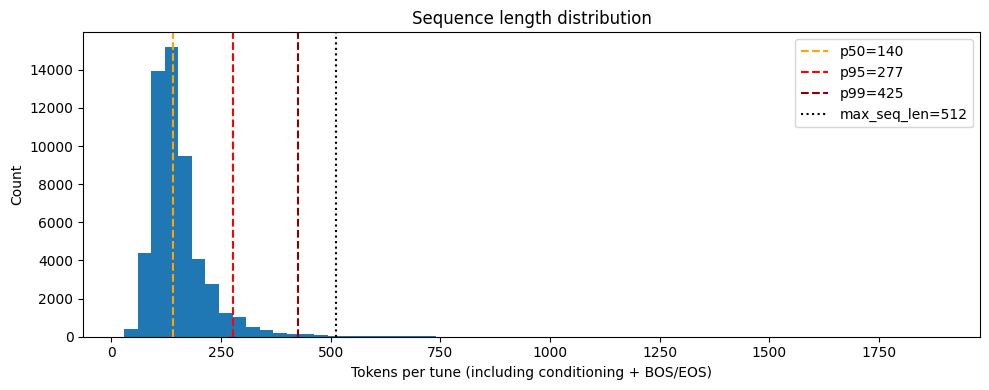

min=29  median=140  mean=153.5  max=1887
Tunes truncated at 512 tokens: 0.5%


In [6]:
seq_lens = [len(tokenizer.encode(t['abc'], t['type'], t['mode'])) for t in tunes]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(seq_lens, bins=60, edgecolor='none')
for pct, color in [(50, 'orange'), (95, 'red'), (99, 'darkred')]:
    val = sorted(seq_lens)[int(len(seq_lens) * pct / 100)]
    ax.axvline(val, color=color, linestyle='--', label=f'p{pct}={val}')
ax.axvline(512, color='black', linestyle=':', label='max_seq_len=512')
ax.set_xlabel('Tokens per tune (including conditioning + BOS/EOS)')
ax.set_ylabel('Count')
ax.set_title('Sequence length distribution')
ax.legend()
plt.tight_layout()
plt.show()

import statistics
print(f'min={min(seq_lens)}  median={statistics.median(seq_lens):.0f}  '
      f'mean={statistics.mean(seq_lens):.1f}  max={max(seq_lens)}')
pct_truncated = sum(1 for l in seq_lens if l > 512) / len(seq_lens) * 100
print(f'Tunes truncated at 512 tokens: {pct_truncated:.1f}%')

## 4. Tokenize a real tune — step by step

In [7]:
# Pick a well-known reel in G major
reel = next(t for t in tunes if t['type'] == 'reel' and t['mode'] == 'Gmajor')

print('Name :', reel['name'])
print('Type :', reel['type'])
print('Key  :', reel['mode'])
print()
print('ABC body:')
print(reel['abc'])

Name : 'S Iomadh Rud A Chunnaic Mi
Type : reel
Key  : Gmajor

ABC body:
ABBA GEDE|G2AG EGDG|ABBA GEDE|GEDE G2GA|
ABBA GEDE|G2AG EGDG|ABBA GEDE|GEDE G2GD|
G2AB dBAB|dBAB AGED|G2AB dBAB|AGED G2GD|
G2AB dBAB|dBAB AGED|G2AB dBAB|AGED G2GA|


In [8]:
music_tokens = tokenize_abc(reel['abc'])
print(f'{len(music_tokens)} music tokens:')
print(music_tokens)

134 music tokens:
['A', 'B', 'B', 'A', 'G', 'E', 'D', 'E', '|', 'G2', 'A', 'G', 'E', 'G', 'D', 'G', '|', 'A', 'B', 'B', 'A', 'G', 'E', 'D', 'E', '|', 'G', 'E', 'D', 'E', 'G2', 'G', 'A', '|', 'A', 'B', 'B', 'A', 'G', 'E', 'D', 'E', '|', 'G2', 'A', 'G', 'E', 'G', 'D', 'G', '|', 'A', 'B', 'B', 'A', 'G', 'E', 'D', 'E', '|', 'G', 'E', 'D', 'E', 'G2', 'G', 'D', '|', 'G2', 'A', 'B', 'd', 'B', 'A', 'B', '|', 'd', 'B', 'A', 'B', 'A', 'G', 'E', 'D', '|', 'G2', 'A', 'B', 'd', 'B', 'A', 'B', '|', 'A', 'G', 'E', 'D', 'G2', 'G', 'D', '|', 'G2', 'A', 'B', 'd', 'B', 'A', 'B', '|', 'd', 'B', 'A', 'B', 'A', 'G', 'E', 'D', '|', 'G2', 'A', 'B', 'd', 'B', 'A', 'B', '|', 'A', 'G', 'E', 'D', 'G2', 'G', 'A', '|']


In [9]:
ids = tokenizer.encode(reel['abc'], reel['type'], reel['mode'])
print(f'Encoded ({len(ids)} IDs):')
print(ids[:20], '...')

print()
print('First 10 tokens decoded:')
print(tokenizer.decode_to_tokens(ids[:10]))

Encoded (138 IDs):
[10, 36, 1, 161, 209, 209, 161, 380, 314, 280, 314, 924, 406, 161, 380, 314, 380, 280, 380, 924] ...

First 10 tokens decoded:
['<TYPE:reel>', '<KEY:Gmajor>', '<BOS>', 'A', 'B', 'B', 'A', 'G', 'E', 'D']


In [10]:
# Full round-trip
reconstructed = tokenizer.decode_to_abc(ids)
print('Round-tripped ABC:')
print(reconstructed)

Round-tripped ABC:
A B B A G E D E | G2 A G E G D G | A B B A G E D E | G E D E G2 G A | A B B A G E D E | G2 A G E G D G | A B B A G E D E | G E D E G2 G D | G2 A B d B A B | d B A B A G E D | G2 A B d B A B | A G E D G2 G D | G2 A B d B A B | d B A B A G E D | G2 A B d B A B | A G E D G2 G A |


## 5. Edge cases

In [11]:
# Grace notes, inline chords, broken rhythm, decorations
edge_cases = [
    ("Grace notes stripped",     "{g}A2 {fg}B2",   ['A2', 'B2']),
    ("Chord symbols stripped",   '"G"G2 "Am"A2',   ['G2', 'A2']),
    ("Inline chord → first note","[G2D2B2] [FA]",  ['G2', 'F']),
    ("Bang deco stripped",       "!trill!A2 !f!G", ['A2', 'G']),
    ("Decoration tokens",        "~A2 .B",         ['~', 'A2', '.', 'B']),
    ("Broken rhythm",            "A>B c<d",        ['A', '>', 'B', 'c', '<', 'd']),
    ("Accidentals",              "^F2 _B =C",      ['^F2', '_B', '=C']),
    ("Tuplet",                   "(3ABc",          ['(3', 'A', 'B', 'c']),
    ("Repeat barlines",          "|: G2AB :||",    ['|:', 'G2', 'A', 'B', ':|', '||']),
    ("Endings [1 style",         "|: AB [1 G4 :|[2 A4 |]", ['|:', 'A', 'B', '[1', 'G4', ':|', '[2', 'A4', '|]']),
    ("Endings |1 style",         "|: AB |1 G4 :|2 A4 |]",  ['|:', 'A', 'B', '|1', 'G4', ':|', '|2', 'A4', '|]']),
]

print(f"{'Case':<30} {'Pass'}")
print('-' * 100)
all_pass = True
for name, abc, expected in edge_cases:
    got = tokenize_abc(abc)
    ok = got == expected
    all_pass = all_pass and ok
    status = '✓' if ok else '✗'
    print(f'{name:<30} {status}')
    if not ok:
        print(f'  expected: {expected}')
        print(f'  got:      {got}')

print()
print('All pass:', all_pass)

Case                           Pass
----------------------------------------------------------------------------------------------------
Grace notes stripped           ✓
Chord symbols stripped         ✓
Inline chord → first note      ✓
Bang deco stripped             ✓
Decoration tokens              ✓
Broken rhythm                  ✓
Accidentals                    ✓
Tuplet                         ✓
Repeat barlines                ✗
  expected: ['|:', 'G2', 'A', 'B', ':|', '||']
  got:      ['|:', 'G2', 'A', 'B', ':|', '|']
Endings [1 style               ✓
Endings |1 style               ✗
  expected: ['|:', 'A', 'B', '|1', 'G4', ':|', '|2', 'A4', '|]']
  got:      ['|:', 'A', 'B', '|1', 'G4', ':|', 'A4', '|]']

All pass: False


In [12]:
# Ending markers specifically — check [1 and |1 styles both captured
print('Ending marker styles:')
print('  [1 style:', tokenize_abc('|: G2AB [1 G4 :|[2 A4 |]'))
print('  |1 style:', tokenize_abc('|: G2AB |1 G4 :|2 A4 |]'))

Ending marker styles:
  [1 style: ['|:', 'G2', 'A', 'B', '[1', 'G4', ':|', '[2', 'A4', '|]']
  |1 style: ['|:', 'G2', 'A', 'B', '|1', 'G4', ':|', 'A4', '|]']


In [13]:
# Inline chord first-note extraction
chord_examples = ['[CEG]', '[G2D2B2]', '[FA]', '[=G2c2e2]', '[^F2A2]', '[A,2E2]']
print('Inline chord → first note:')
for c in chord_examples:
    print(f'  {c:20s} → {_first_note_from_chord(c)}')

Inline chord → first note:
  [CEG]                → C
  [G2D2B2]             → G2
  [FA]                 → F
  [=G2c2e2]            → =G2
  [^F2A2]              → ^F2
  [A,2E2]              → A,2


## 6. Conditioning tokens

In [14]:
type_tokens = sorted(t for t in vocab if t.startswith('<TYPE:'))
key_tokens  = sorted(t for t in vocab if t.startswith('<KEY:'))

print(f'Tune type tokens ({len(type_tokens)}):', type_tokens)
print()
print(f'Key/mode tokens ({len(key_tokens)}):', key_tokens)

Tune type tokens (12): ['<TYPE:barndance>', '<TYPE:hornpipe>', '<TYPE:jig>', '<TYPE:march>', '<TYPE:mazurka>', '<TYPE:polka>', '<TYPE:reel>', '<TYPE:slide>', '<TYPE:slip jig>', '<TYPE:strathspey>', '<TYPE:three-two>', '<TYPE:waltz>']

Key/mode tokens (23): ['<KEY:Adorian>', '<KEY:Amajor>', '<KEY:Aminor>', '<KEY:Amixolydian>', '<KEY:Bdorian>', '<KEY:Bminor>', '<KEY:Bmixolydian>', '<KEY:Cdorian>', '<KEY:Cmajor>', '<KEY:Ddorian>', '<KEY:Dmajor>', '<KEY:Dminor>', '<KEY:Dmixolydian>', '<KEY:Edorian>', '<KEY:Emajor>', '<KEY:Eminor>', '<KEY:Emixolydian>', '<KEY:Fdorian>', '<KEY:Fmajor>', '<KEY:Gdorian>', '<KEY:Gmajor>', '<KEY:Gminor>', '<KEY:Gmixolydian>']


In [15]:
# Show a fully encoded sequence prefix
ids = tokenizer.encode(reel['abc'], reel['type'], reel['mode'])
print('Full encoded prefix (first 8 tokens):')
for i, (tok, id_) in enumerate(zip(tokenizer.decode_to_tokens(ids[:8]), ids[:8])):
    print(f'  [{i}] id={id_:4d}  token={tok}')

Full encoded prefix (first 8 tokens):
  [0] id=  10  token=<TYPE:reel>
  [1] id=  36  token=<KEY:Gmajor>
  [2] id=   1  token=<BOS>
  [3] id= 161  token=A
  [4] id= 209  token=B
  [5] id= 209  token=B
  [6] id= 161  token=A
  [7] id= 380  token=G


## 7. Save tokenizer

In [16]:
from pathlib import Path
Path('models').mkdir(exist_ok=True)
tokenizer.save('models/tokenizer.pkl')
print('Saved to models/tokenizer.pkl')

# Reload and verify
tok2 = ABCTokenizer.load('models/tokenizer.pkl')
assert len(tok2) == len(tokenizer)
print(f'Reload OK — vocab size {len(tok2):,}')

Saved to models/tokenizer.pkl
Reload OK — vocab size 932
